<a href="https://colab.research.google.com/github/MAFINPY29/Laboratory-Experiments--Physics-3/blob/main/Experimento-2-Carga-de-condensador/Exp2%20Carga%20de%20condensador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 2: Carga de capacitor

Este notebook presenta el análisis de datos experimentales obtenidos en laboratorio para el estudio de la relación carga-voltaje de un capacitor de placas paralelas, para estimar su capacitancia, en función de su distancia de separación.


## Modelo físico

La relación entre la carga eléctrica y el voltaje en un capacitor es dada por:

$$ Q = C\ V$$

Esta expresión predice una dependencia lineal entre la carga y el voltaje, donde la capacitancia corresponde a la pendiente del ajuste lineal.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_excel("datos.xlsx")
df

,Voltaje,Q1_A,Q2_A,Q3_A,Q1_B,Q2_B,Q3_B
0,50,0.587,0.623,0.676,0.391,0.400,0.38
1,100,1.180,1.170,1.400,0.795,0.783,0.80
2,200,2.700,2.340,2.400,1.600,1.500,1.56
3,300,3.520,3.600,3.450,2.720,2.340,2.50


Las cargas están dadas en nanocoulumbs (nC).

In [3]:
# Separar
df_A = df[["Voltaje", "Q1_A", "Q2_A", "Q3_A"]].copy()
df_B = df[["Voltaje", "Q1_B", "Q2_B", "Q3_B"]].copy()

In [4]:
df_A

,Voltaje,Q1_A,Q2_A,Q3_A
0,50,0.587,0.623,0.676
1,100,1.180,1.170,1.400
2,200,2.700,2.340,2.400
3,300,3.520,3.600,3.450


In [5]:
df_B

,Voltaje,Q1_B,Q2_B,Q3_B
0,50,0.391,0.400,0.38
1,100,0.795,0.783,0.80
2,200,1.600,1.500,1.56
3,300,2.720,2.340,2.50


In [6]:
# Promedio y error estándar
df_A["Q_mean"] = df_A.iloc[:,1:].mean(axis=1)
df_A["Q_std"] = df_A.iloc[:,1:4].std(axis=1, ddof=1)
df_A["Q_sem"] = df_A["Q_std"] / np.sqrt(3)

df_B["Q_mean"] = df_B.iloc[:,1:].mean(axis=1)
df_B["Q_std"] = df_B.iloc[:,1:4].std(axis=1, ddof=1)
df_B["Q_sem"] = df_B["Q_std"] / np.sqrt(3)

In [7]:
df_A

,Voltaje,Q1_A,Q2_A,Q3_A,Q_mean,Q_std,Q_sem
0,50,0.587,0.623,0.676,0.628667,0.044770,0.025848
1,100,1.180,1.170,1.400,1.250000,0.130000,0.075056
2,200,2.700,2.340,2.400,2.480000,0.192873,0.111355
3,300,3.520,3.600,3.450,3.523333,0.075056,0.043333


In [8]:
df_B

,Voltaje,Q1_B,Q2_B,Q3_B,Q_mean,Q_std,Q_sem
0,50,0.391,0.400,0.38,0.390333,0.010017,0.005783
1,100,0.795,0.783,0.80,0.792667,0.008737,0.005044
2,200,1.600,1.500,1.56,1.553333,0.050332,0.029059
3,300,2.720,2.340,2.50,2.520000,0.190788,0.110151


In [9]:
# Ajuste lineal

slope_A, intercept_A, r_A, p_A, std_err_A = stats.linregress(
    df_A["Voltaje"], df_A["Q_mean"]
)

slope_B, intercept_B, r_B, p_B, std_err_B = stats.linregress(
    df_B["Voltaje"], df_B["Q_mean"]
)

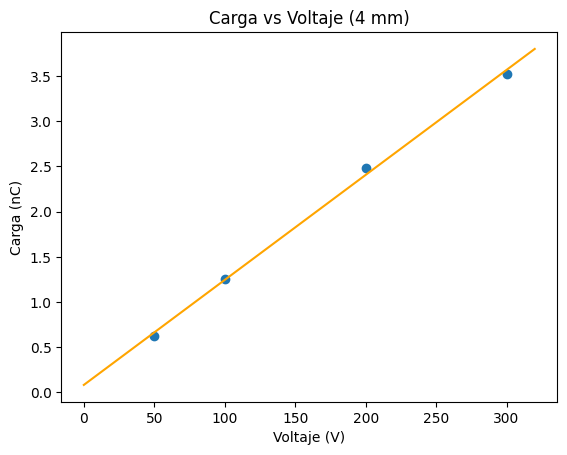

In [10]:
# Gráfica (d = 4 mm)

x_line = np.linspace(0, 320, 100)

plt.figure()

plt.scatter(df_A["Voltaje"], df_A["Q_mean"])
plt.plot(x_line, slope_A*x_line + intercept_A, color = "orange")
plt.xlabel("Voltaje (V)")
plt.ylabel("Carga (nC)")
plt.title("Carga vs Voltaje (4 mm)")
plt.show()


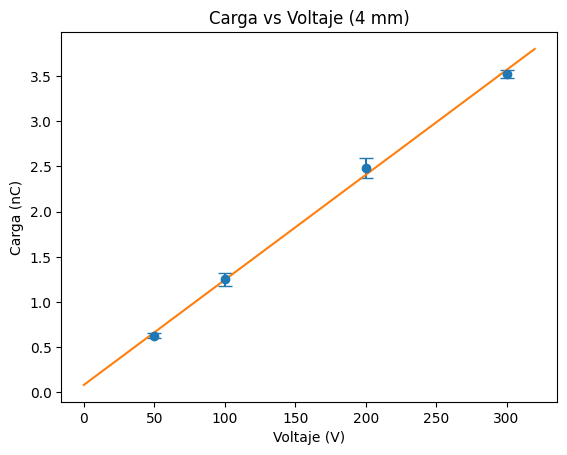

In [11]:
# Gráfica con error (4 mm)

plt.figure()

plt.errorbar(
    df_A["Voltaje"], df_A["Q_mean"],
    yerr=df_A["Q_sem"], fmt='o', capsize=5
)

plt.plot(x_line, slope_A*x_line + intercept_A)

plt.xlabel("Voltaje (V)")
plt.ylabel("Carga (nC)")
plt.title("Carga vs Voltaje (4 mm)")
plt.show()


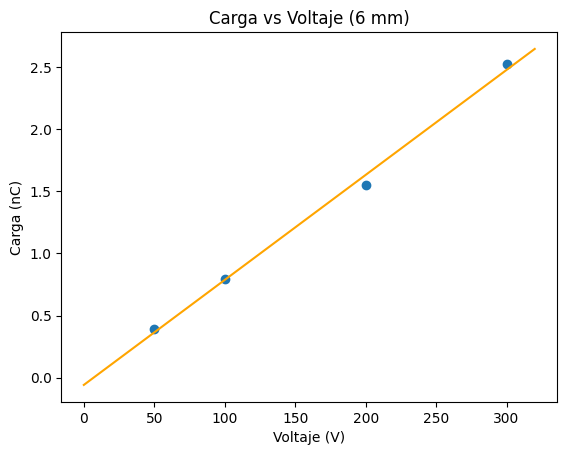

In [12]:
# Gráfica (d = 6 mm)

plt.figure()

plt.scatter(df_B["Voltaje"], df_B["Q_mean"])
plt.plot(x_line, slope_B*x_line + intercept_B, color = "orange")

plt.xlabel("Voltaje (V)")
plt.ylabel("Carga (nC)")
plt.title("Carga vs Voltaje (6 mm)")
plt.show()


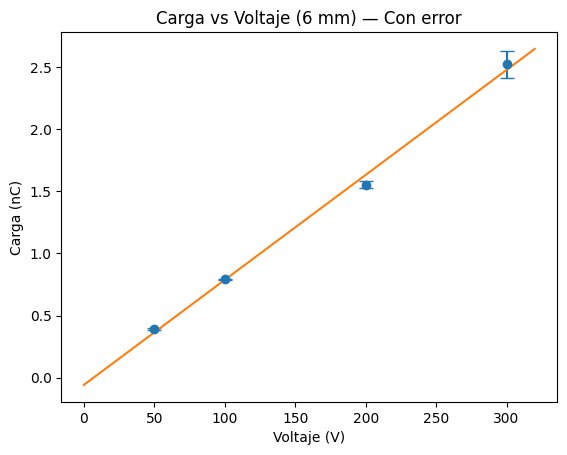

In [13]:
# Gráfica con error (6 mm)

plt.figure()

plt.errorbar(
    df_B["Voltaje"], df_B["Q_mean"],
    yerr=df_B["Q_sem"], fmt='o', capsize=5
)

plt.plot(x_line, slope_B*x_line + intercept_B)

plt.xlabel("Voltaje (V)")
plt.ylabel("Carga (nC)")
plt.title("Carga vs Voltaje (6 mm) — Con error")
plt.show()

In [14]:
print("===== RESULTADOS =====")
print("Para la separación de 4 mm, se obtuvo que la capacitancia viene dada por:")
print(f"4 mm: C = {slope_A:.6f} ± {std_err_A:.6f} nF")
print(f"Intercepto = {intercept_A:.6f}")
print(f"R² = {r_A**2:.6f}\n")

print("Para la separación de 6 mm, se obtuvo que la capacitancia viene dada por:")
print(f"6 mm: C = {slope_B:.6f} ± {std_err_B:.6f} nF")
print(f"Intercepto = {intercept_B:.6f}")
print(f"R² = {r_B**2:.6f}")


===== RESULTADOS =====
Para la separación de 4 mm, se obtuvo que la capacitancia viene dada por:
4 mm: C = 0.011623 ± 0.000343 nF
Intercepto = 0.081718
R² = 0.998260

Para la separación de 6 mm, se obtuvo que la capacitancia viene dada por:
6 mm: C = 0.008442 ± 0.000344 nF
Intercepto = -0.057729
R² = 0.996689


Notemos que la pendiente para 4mm es mayor que 6 mm, lo que indica que, la capacitancia del capacitor será cada vez menor cuando sus placas estén más separadas (relacion inversa)